In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score,roc_curve,accuracy_score,precision_score,f1_score,r2_score,recall_score

import warnings
warnings.filterwarnings('ignore')


In [4]:
df=pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\Machine learning\Machine_learning_practice\LOGISTIC_REGRESSION\Bank Customer Churn Prediction (1).csv')

In [5]:
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [7]:
df.shape

(10000, 12)

In [9]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
# Data profiling & quality
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [15]:
categorical_cols=df.select_dtypes(include='object').columns
print("\nUnique category counts:")
for col in categorical_cols:
    print(col,":",df[col].nunique())


Unique category counts:
country : 3
gender : 2


# ---------------------------
# INTERVIEW Q1:
# Why data cleaning is critical in banking churn?
# ---------------------------
"""
In financial services, poor data quality can lead to incorrect churn risk predictions,
causing banks to either lose valuable customers or waste retention budgets.
Clean data ensures regulatory compliance, reliable risk assessment, and trust in decisions.
"""

In [17]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

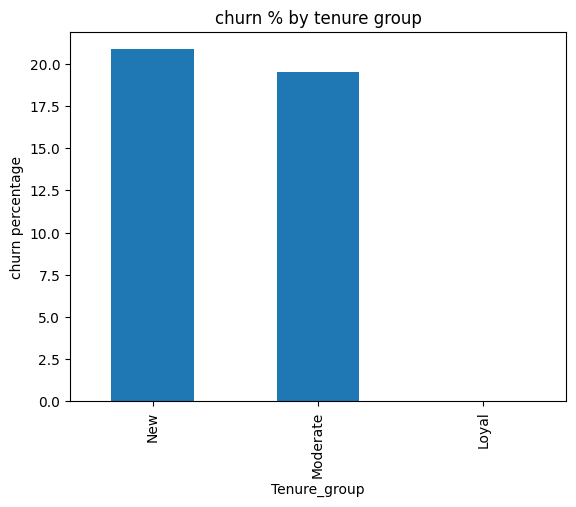

In [21]:
df['Tenure_group']=pd.cut(
    df['tenure'],
    bins=[-1,6,24,100],
    labels=['New','Moderate','Loyal']
)
tenure_churn=df.groupby('Tenure_group')['churn'].mean()*100
tenure_churn.plot(kind='bar',title='churn % by tenure group')
plt.ylabel('churn percentage')
plt.show()


# Business Insight
"""
New customers show the highest churn.
Action: Improve onboarding, early engagement offers, and first-year incentives.
"""


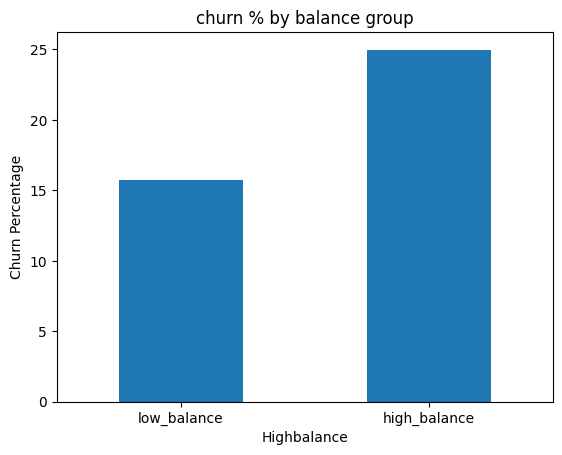

In [24]:
# ---------------------------
# 5. REVENUE & BALANCE EDA
# ---------------------------

balance_median= df['balance'].median()
df['Highbalance']=np.where(df['balance']>balance_median,1,0)
balance_churn=df.groupby('Highbalance')['churn'].mean()*100
balance_churn.plot(kind='bar',title='churn % by balance group')
plt.ylabel("Churn Percentage")
plt.xticks([0,1],['low_balance','high_balance'],rotation=0)
plt.show()


# ---------------------------
# 6. FEATURE INTERACTION EDA
# ---------------------------

In [25]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'Tenure_group', 'Highbalance'],
      dtype='object')

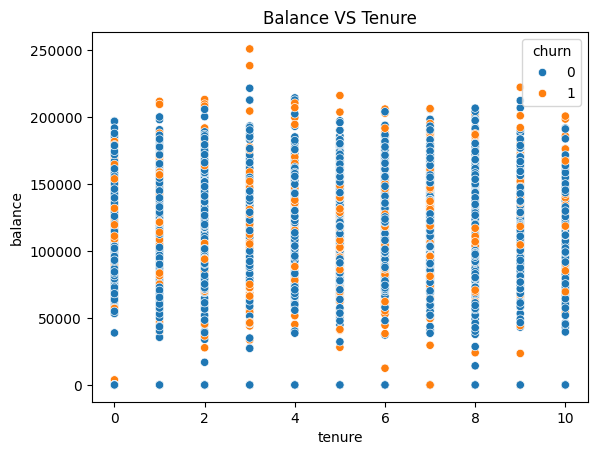

In [26]:
sns.scatterplot(x='tenure',y='balance',hue='churn',data=df)
plt.title("Balance VS Tenure")
plt.show()

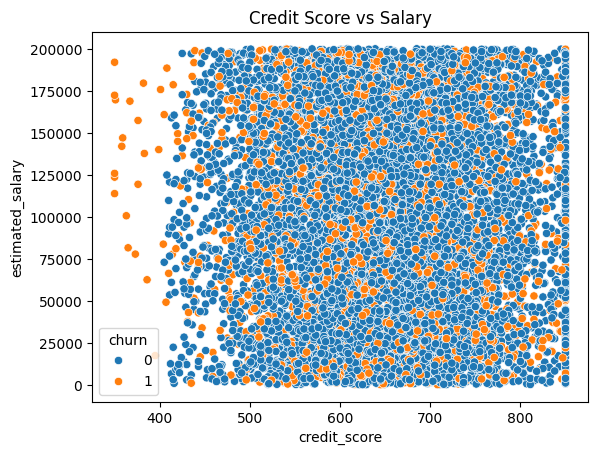

In [27]:
sns.scatterplot(data=df,x='credit_score',y='estimated_salary',hue='churn')
plt.title("Credit Score vs Salary")
plt.show()


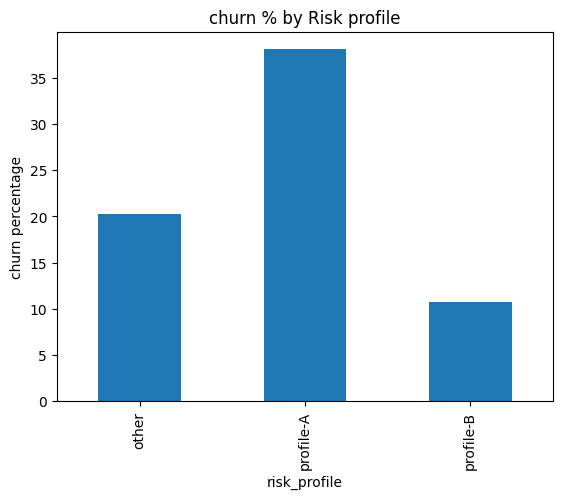

In [31]:
df['risk_profile'] = np.where(
    (df['age'] > 45) & (df['balance'] < balance_median),
    'profile-A',
    np.where(
        (df['age'] < 35) & (df['balance'] > balance_median),
        'profile-B',
        'other'
    )
)

risk_churn=df.groupby('risk_profile')['churn'].mean()*100
risk_churn.plot(kind='bar',title='churn % by Risk profile')
plt.ylabel('churn percentage')
plt.show()

In [32]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'Tenure_group', 'Highbalance',
       'risk_profile'],
      dtype='object')


# ---------------------------
# 8. STATISTICAL ASSOCIATION
# ---------------------------
# Chi-Square for categorical features

In [33]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from scipy.stats import chi2_contingency

In [41]:
from scipy.stats import chi2_contingency

cat_features = ['country', 'gender', 'credit_card', 'active_member']

for col in cat_features:
    table = pd.crosstab(df[col], df['churn'])
    chi2, p, dof, expected = chi2_contingency(table)

    print(f"{col} → p-value: {p:.4f}")

country → p-value: 0.0000
gender → p-value: 0.0000
credit_card → p-value: 0.4924
active_member → p-value: 0.0000



# ---------------------------
# 9. FEATURE ENGINEERING
# ---------------------------

In [42]:
df['MultiproductFlag']=np.where(df['products_number']>1,1,0)

# 10. PREPROCESSING

In [ ]:
X = df.drop(['churn','Tenure_Group','Risk_Profile'], axis=1)
y = df['churn']

num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first'), cat_features)
])

In [43]:
X = df.drop(['churn', 'Tenure_group', 'risk_profile'], axis=1)
y = df['churn']

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)


# ---------------------------
# 12. HANDLE IMBALANCE (SMOTE)
# ---------------------------

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

# ---------------------------
# 13. BASELINE LOGISTIC REGRESSION
# ---------------------------

In [47]:
# ---------------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_resampled, y_resampled)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [48]:
y_pred = lr.predict(X_test_processed)
y_prob = lr.predict_proba(X_test_processed)[:,1]

In [50]:
print("\nBaseline Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Baseline Logistic Regression Metrics:
Accuracy: 0.7273333333333334
Precision: 0.40336134453781514
Recall: 0.707037643207856
F1: 0.5136741973840666
ROC-AUC: 0.7911191433184968


In [51]:
# ---------------------------
# 14. REGULARIZED MODELS
# ---------------------------
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
lr_l2 = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)

lr_l1.fit(X_resampled, y_resampled)
lr_l2.fit(X_resampled, y_resampled)

print("\nL1 ROC-AUC:", roc_auc_score(y_test, lr_l1.predict_proba(X_test_processed)[:,1]))
print("L2 ROC-AUC:", roc_auc_score(y_test, lr_l2.predict_proba(X_test_processed)[:,1]))



L1 ROC-AUC: 0.791169154314065
L2 ROC-AUC: 0.7911184582363657
